This notebook was used to run each model configuration below on FOMC, BoE, RBA and combined minutes text from central_bank_minutes_labeled.csv (generated from upstream data_pipeline.ipynb). Please see list of four model configs below:

  - majority-class baseline: assumes hold for each example
  - TF-IDF + Logistic Regression: lexical model baseline
  - Frozen FinBERT (Chuncked) + Logistic Regression: domain-specific with 512 token limit
  - Frozen ModernBERT + Logistic Regression: general context transformer with 8,192 token limit, no chunking required

Data is split temporally:

  - train: 2000-2019
  - test: 2020-2026

Primary Metrics Used for Analysis:

  - F1 Macro: handles class imbalance (75% hold, 25% change)
  - Precision
  - Recall

Claude Sonnet 4.6 was used in this notebook to assist with debugging, print statement formatting, FinBERT chunking and encoding logic, and Figure 1 plot formatting (the latter two were rather complex to properly write on my own without assistance).

In [4]:
# install necessary packages and imports, including transformers and scikit-learn
!pip install transformers torch scikit-learn pandas numpy -q

# connect google drive
from google.colab import drive
drive.mount('/content/drive')

# ignore pesky warnings
import warnings
warnings.filterwarnings('ignore')

# import all other needed packages
import re
import torch
import pandas as pd
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression # logistic regression
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF
from sklearn.metrics import (
    f1_score
    , precision_score
    , recall_score
    , accuracy_score)

# import transformers for tokenizer
from transformers import AutoTokenizer, AutoModel

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# import central_bank_minutes_labeled.csv
df = pd.read_csv('/content/drive/MyDrive/central_bank_minutes_labeled.csv')

# convert meeting date to datetime
df['meeting_date'] = pd.to_datetime(df['meeting_date'])

# add year column
df['year'] = df['meeting_date'].dt.year

In [7]:
# confirm counts for each central bank prior to train/test split
df.groupby(['bank', 'label']).size()

bank  label 
BoE   change     52
      hold      201
FOMC  change     68
      hold      168
RBA   change     48
      hold      159
dtype: int64

In [9]:
# define a function to remove years from text prior to training to avoid temporal data leakage and memorization
def remove_years(text):
    # use regex to identify dates with "19" or "20" in text to remove and convert to empty string
    return re.sub(r'\b(19|20)\d{2}\b', '', str(text))

# define basic temporal train/test split function
def get_split(data):
    # create train and test dfs for modeling
    train = data[data['year'] <= 2019].copy()
    test  = data[data['year'] >= 2020].copy()
    return train, test

# define metrics function to capture each primary metric for analysis downstream, rounded to 3 decimals for visuals
def metrics(y_true, y_pred, y_prob = None):
    return {'f1_macro': round(f1_score(y_true, y_pred, average = 'macro'), 3) # calculate F1 macro from F1 score (more heavily penalizes minority class mislabels)
            , 'precision_change': round(precision_score(y_true, y_pred, pos_label = 'change', average = 'binary', zero_division = 0), 3) # precision
            , 'recall_change': round(recall_score(y_true, y_pred, pos_label = 'change', average = 'binary', zero_division = 0), 3) # recall
            , 'accuracy': round(accuracy_score(y_true, y_pred), 3),} # overall accuracy

In [11]:
# append FOMC, BoE, RBA, and combined dfs to config dict
configs = {
    'FOMC': df[df['bank'] == 'FOMC']
    , 'BoE': df[df['bank'] == 'BoE']
    , 'RBA': df[df['bank'] == 'RBA']
    , 'Combined': df,
}

In [16]:
# confirm get_split returns appropriate counts for each config
for name, data in configs.items():
    train, test = get_split(data)
    print(f'{name}: train = {len(train)}')
    print(f'test = {len(test)}')
    print('-'*20)

FOMC: train = 186
test = 50
--------------------
BoE: train = 204
test = 49
--------------------
RBA: train = 145
test = 62
--------------------
Combined: train = 535
test = 161
--------------------


In [23]:
# initialize results list
all_results = []

# run majority-class baseline on each config using the sklearn dummy classifier, calculate baseline metrics

for name, data in configs.items():
    # get train and test dfs
    train, test = get_split(data)

    # run sklearn dummy classifier
    clf = DummyClassifier(strategy = 'most_frequent') # majority class used as strategy
    clf.fit(train[['year']], train['label'])

    # predict test labels with majority class
    y_pred = clf.predict(test[['year']])

    # get metrics and append to all_results list
    m = metrics(test['label'].values, y_pred)
    m.update({'config': name, 'model': 'Baseline'})
    all_results.append(m)

    # print results to view relative baseline performance in terms of F1 macro
    print(f'{name}: F1 macro = {m["f1_macro"]}')

FOMC: F1 macro = 0.405
BoE: F1 macro = 0.372
RBA: F1 macro = 0.421
Combined: F1 macro = 0.401


In [24]:
# run TF-IDF (lexical baseline, year tokens removed) and train logistic regression model

for name, data in configs.items():
    # get train and test dfs
    train, test = get_split(data)

    # initialize TF-IDF, remove years from text, and fit and transform
    vec = TfidfVectorizer(max_features = 10000    # limited to top 10,000 most frequent terms
                          , ngram_range = (1, 2)  # include both single and two word phrases
                          , min_df = 2)           # word must appear in at least 2 documents to be included
    X_train = vec.fit_transform(train['text'].apply(remove_years))
    X_test = vec.transform(test['text'].apply(remove_years))

    # train, fit, and make predictions with lositic regression classifier
    clf = LogisticRegression(class_weight = 'balanced'  # manages class imbalance
                              , max_iter = 1000         # default 100, 10X more iterations added
                              , C = 1.0)                # default L2 regularization to manage overfitting
    clf.fit(X_train, train['label'])
    y_pred = clf.predict(X_test)

    # get metrics and update config
    m = metrics(test['label'].values, y_pred)
    m.update({'config': name, 'model': 'TF-IDF + LR'})

    # append to all_results list and print
    all_results.append(m)
    print(f'{name}: F1 macro = {m["f1_macro"]} | Precision = {m["precision_change"]} | Recall = {m["recall_change"]}')

FOMC: F1 macro=0.405 | Prec=0.0 | Rec=0.0
BoE: F1 macro=0.372 | Prec=0.0 | Rec=0.0
RBA: F1 macro=0.621 | Prec=0.467 | Rec=0.412
Combined: F1 macro=0.592 | Prec=0.636 | Rec=0.264


In [26]:
# init device to check whether cuda GPU is available, else use CPU

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize autotokenizer and automodel for ModernBERT from answerdotai using device for compute
mb_tokenizer = AutoTokenizer.from_pretrained('answerdotai/ModernBERT-base')
mb_model = AutoModel.from_pretrained('answerdotai/ModernBERT-base').to(device)
mb_model.eval()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ModernBertModel(
  (embeddings): ModernBertEmbeddings(
    (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
    (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (layers): ModuleList(
    (0): ModernBertEncoderLayer(
      (attn_norm): Identity()
      (attn): ModernBertAttention(
        (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
        (Wo): Linear(in_features=768, out_features=768, bias=False)
        (out_drop): Identity()
      )
      (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): ModernBertMLP(
        (Wi): Linear(in_features=768, out_features=2304, bias=False)
        (act): GELUActivation()
        (drop): Dropout(p=0.0, inplace=False)
        (Wo): Linear(in_features=1152, out_features=768, bias=False)
      )
    )
    (1-21): 21 x ModernBertEncoderLayer(
      (attn_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): ModernBertAt

In [27]:
# encode ModernBERT with frozen encoder weights using max token length for full document (typicaly 3-7k words)
def encode_modernbert(texts, batch_size = 4, max_length = 8192):
    # init list of embeddings
    all_embs = []
    texts = list(texts)

    # loop through all documents in parallel batches, up to 4 per batch
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc   = mb_tokenizer(batch
                             , max_length = max_length
                             , truncation = True
                             , padding = True
                             , return_tensors = 'pt').to(device)

        # disable gradient descent, weights frozen
        with torch.no_grad():
            out = mb_model(**enc)

        # mean-pooling to get 768-dimensional feature vector
        embs = out.last_hidden_state.mean(dim = 1).cpu().numpy() # result moved back to cpu for more optimal numpy computation
        all_embs.append(embs)

    # combine into single array and return result
    return np.vstack(all_embs)

In [28]:
# reset df index
df_r = df.reset_index(drop = True)

# run encode_modernbert() on all 696 documents
mb_embeddings = encode_modernbert(df_r['text'])

# define index for easier lookup
df_r['mb_idx'] = range(len(df_r))

In [29]:
# loop through each bank configuration
for name, data in configs.items():
    data = data.copy()

    # map each row position to embeddings
    data['mb_idx'] = df_r.loc[data.index, 'mb_idx'].values

    # train/test split
    train, test = get_split(data)

    # get train and test embeddings
    X_train = mb_embeddings[train['mb_idx'].values]
    X_test = mb_embeddings[test['mb_idx'].values]

    #train, fit, and make predictions with logistic regression classifier
    clf = LogisticRegression(class_weight = 'balanced'  # manages class imbalance
                              , max_iter = 1000         # default 100, 10X more iterations added
                              , C = 1.0)                # default L2 regularization to manage overfitting
    clf.fit(X_train, train['label'])
    y_pred = clf.predict(X_test)

    # get metrics and update config dict
    m = metrics(test['label'].values, y_pred)
    m.update({'config': name, 'model': 'ModernBERT + LR'})

    # apend to all_results list and print
    all_results.append(m)
    print(f'  {name}: F1 macro = {m["f1_macro"]} | Precision = {m["precision_change"]} | Recall = {m["recall_change"]}')

  FOMC: F1 macro=0.69 | Prec=0.52 | Rec=0.812
  BoE: F1 macro=0.424 | Prec=0.333 | Rec=0.1
  RBA: F1 macro=0.669 | Prec=0.464 | Rec=0.765
  Combined: F1 macro=0.627 | Prec=0.51 | Rec=0.472


In [30]:
# save FOMC results to use for Figure 1 plot

for name, data in configs.items():
    data = data.copy()

    if name == 'FOMC':
        fomc_test = test.copy().reset_index(drop = True)
        fomc_test['pred']  = y_pred
        fomc_test['error_type'] = 'correct'
        fomc_test.loc[(fomc_test['pred'] == 'change') & (fomc_test['label'] == 'hold'),  'error_type'] = 'false_positive'
        fomc_test.loc[(fomc_test['pred'] == 'hold')   & (fomc_test['label'] == 'change'), 'error_type'] = 'false_negative'
        test_results = fomc_test

In [31]:
# initialize autotokenizer and automodel for FinBERT from yianghkust
fb_tokenizer = AutoTokenizer.from_pretrained('yiyanghkust/finbert-tone')
fb_model = AutoModel.from_pretrained('yiyanghkust/finbert-tone').to(device)
fb_model.eval()

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30873, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [32]:
# encode FinBERT with chunking strategy: 20 chunks per document with 64 token overlap, and mean-pooled to represent a single document

CHUNK_SIZE = 510
CHUNK_OVERLAP = 64 # preserve context at chunk boundaries

def encode_finbert_chunked(texts, batch_size=16):
    all_doc_embs = []

    for doc_idx, text in enumerate(list(texts)):

        # tokenize each full document without truncating and get token ids
        token_ids = fb_tokenizer.encode(str(text)
                                        , add_special_tokens = False  # don't add CLS at this step
                                        , truncation = False)         # no truncation
        chunks_input_ids, chunks_attn_mask = [], []

        # get overlapping step size: 446 tokens
        stride = CHUNK_SIZE - CHUNK_OVERLAP

        # loop through document, create one chunk per stride
        for start in range(0, max(1, len(token_ids)), stride):
            chunk = token_ids[start:start + CHUNK_SIZE]

            # pass if reaching end of document
            if len(chunk) < 5:
                break

            # add CLS token at start and SEP at the end of chunk for FinBERT
            chunk_with_special = [fb_tokenizer.cls_token_id] + chunk + [fb_tokenizer.sep_token_id]

            # calculate how many padding tokens needed
            pad_len = (CHUNK_SIZE + 2) - len(chunk_with_special)

            # attention mask: 1 for real tokens, 0 for padding tokens
            attn = [1] * len(chunk_with_special) + [0] * pad_len

            # append padding tokens to get uniform sequence length, store attention mask
            chunk_with_special = chunk_with_special + [fb_tokenizer.pad_token_id] * pad_len
            chunks_input_ids.append(chunk_with_special)
            chunks_attn_mask.append(attn)

            # pass if 20 chunks have been created
            if len(chunks_input_ids) >= 20:
                break

        # error handling if document produces zero chunks
        if not chunks_input_ids:
            all_doc_embs.append(np.zeros(768))
            continue

        chunk_embs = []

        # loop through document chunks in batches of 16 for GPU effciency
        for i in range(0, len(chunks_input_ids), batch_size):

            # convert to pytorch tensors, move to GPU
            ids  = torch.tensor(chunks_input_ids[i:i + batch_size], dtype = torch.long).to(device)
            mask = torch.tensor(chunks_attn_mask[i:i + batch_size], dtype = torch.long).to(device)

            # disable gradient descent, weights frozen
            with torch.no_grad():

                # pass batches of chunks to FinBERT
                out = fb_model(input_ids = ids, attention_mask = mask)

            # append all chunk embeddings for current document
            chunk_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())

        # mean-pool all chunk embeddings into single 768-dimensional vector (whole document)
        all_doc_embs.append(np.vstack(chunk_embs).mean(axis = 0))

    # stack all 696 document embeddings and return
    return np.vstack(all_doc_embs)

In [33]:
# run chunked encoding function on all docs
fb_embeddings = encode_finbert_chunked(df_r['text'])

# get row index for embedding lookup
df_r['fb_idx'] = range(len(df_r))

# loop and run through all configs
for name, data in configs.items():
    data = data.copy()

    # map embedding positions to subset
    data['fb_idx'] = df_r.loc[data.index, 'fb_idx'].values

    train, test = get_split(data)
    X_train = fb_embeddings[train['fb_idx'].values]
    X_test = fb_embeddings[test['fb_idx'].values]

    # train, fit, and make predictions with logistic regression classifer
    clf = LogisticRegression(class_weight = 'balanced' # manages class imabalance
                                , max_iter = 1000         # default 100, 10X more iterations added
                                , C = 1.0)                # default L2 regularization to manage overfitting
    clf.fit(X_train, train['label'])
    y_pred = clf.predict(X_test)

    # get metrics and update config dict
    m = metrics(test['label'].values, y_pred)
    m.update({'config': name, 'model': 'FinBERT Chunked + LR'})

    # append to all_results list and print
    all_results.append(m)
    print(f'{name}: F1 macro = {m["f1_macro"]} | Precision = {m["precision_change"]} | Recall = {m["recall_change"]}')

FOMC: F1 macro = 0.62 | Precision = 0.457 | Recall = 1.0
BoE: F1 macro = 0.403 | Precision = 0.333 | Recall = 0.05
RBA: F1 macro = 0.578 | Precision = 0.375 | Recall = 0.706
Combined: F1 macro = 0.625 | Precision = 0.5 | Recall = 0.491


In [34]:
# print a pivoted summary of results from all model runs
results_df = pd.DataFrame(all_results)
pivot = results_df.pivot(index = 'model'
                          , columns = 'config'
                          , values = 'f1_macro')
pivot = pivot[['FOMC', 'BoE', 'RBA', 'Combined']]
pivot.index.name = 'Model'

print(pivot.to_string())
fomc_results = results_df[results_df['config'] == 'FOMC'][['model', 'precision_change', 'recall_change']]
print(fomc_results.to_string(index = False))

config                 FOMC    BoE    RBA  Combined
Model                                              
Baseline              0.405  0.372  0.421     0.401
FinBERT Chunked + LR  0.620  0.403  0.578     0.625
ModernBERT + LR       0.690  0.424  0.669     0.627
TF-IDF + LR           0.405  0.372  0.621     0.592
               model  precision_change  recall_change
            Baseline             0.000          0.000
         TF-IDF + LR             0.000          0.000
     ModernBERT + LR             0.520          0.812
FinBERT Chunked + LR             0.457          1.000


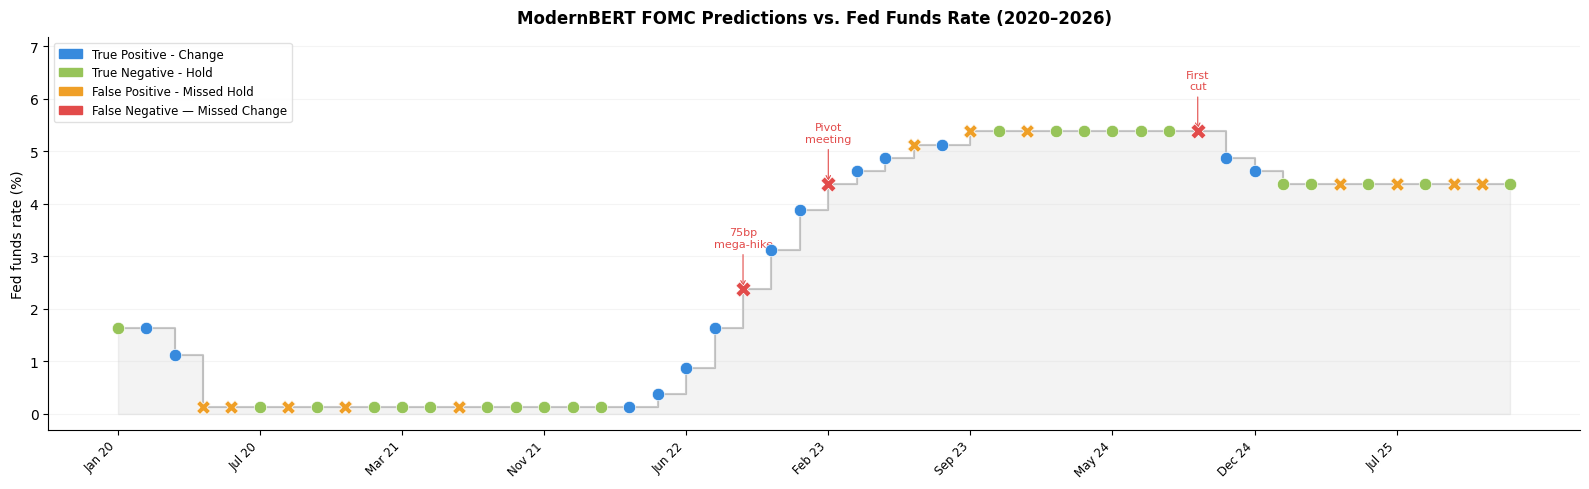

Saved.


In [46]:
# generate Figure 1, combining FOMC test labels from ModernBERT and

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# rebuild test_results from scratch using rate_before
fomc_df = df[df['bank'] == 'FOMC'].copy()
fomc_df['mb_idx'] = df_r.loc[fomc_df.index, 'mb_idx'].values
train_f, test_f = get_split(fomc_df)

# re-run Logistic regression classifier for FOMC data and config specifically
clf_fomc = LogisticRegression(class_weight = 'balanced' # manages class imbalance
                              , max_iter = 1000         # default 100, 10X more iterations added
                              , C = 1.0)                # default L2 regularization to manage overfitting
clf_fomc.fit(mb_embeddings[train_f['mb_idx'].values], train_f['label'])
y_pred_f = clf_fomc.predict(mb_embeddings[test_f['mb_idx'].values])

# copy test FOMC df and reset index
test_results = test_f.copy().reset_index(drop = True)

# use preds to determine correct and incorrect labels
test_results['pred'] = y_pred_f
test_results['error_type'] = 'correct'
test_results.loc[(test_results['pred'] == 'change') & (test_results['label'] == 'hold'), 'error_type'] = 'false_positive'
test_results.loc[(test_results['pred'] == 'hold')   & (test_results['label'] == 'change'), 'error_type'] = 'false_negative'

# generate plot with subplots for both series: fed funds rate and ModernBERT labels
plot_df = test_results.sort_values('meeting_date').reset_index(drop = True)
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# add fed funds rate plots to
x = np.arange(len(plot_df))
rate = plot_df['rate_before'].values

# create staircase line to connect each different rate levels with shading applied below
ax.step(x, rate, where = 'post', color = '#ccc', linewidth = 1.5, zorder = 1)
ax.fill_between(x, rate, alpha = 0.06, color = '#333', step = 'post')

# loop through each FOMC meeting in test data and assign correct shape and color corresponding to each label outcome
for i, (_, r) in enumerate(plot_df.iterrows()):
    y = rate[i]
    if r['error_type'] == 'correct' and r['label'] == 'change':   # true positive
        color, marker, size, zorder = '#378ADD', 'o', 80, 4
    elif r['error_type'] == 'correct' and r['label'] == 'hold':   # true negative
        color, marker, size, zorder = '#97C459', 'o', 80, 4
    elif r['error_type'] == 'false_positive':                     # false positive
        color, marker, size, zorder = '#EF9F27', 'X', 100, 5
    else:                                                         # false negative
        color, marker, size, zorder = '#E24B4A', 'X', 120, 6
    ax.scatter(i, y, c=color, marker=marker, s=size,
               zorder=zorder, edgecolors='white', linewidth=0.5)

# add annotations to critical false negative examples
annots = {
    '2022-09': '75bp\nmega-hike'
    , '2023-02': 'Pivot\nmeeting'
    , '2024-09': 'First\ncut'
}

# identify false negative plot points
for date_str, label in annots.items():
    mask = plot_df['meeting_date'].dt.strftime('%Y-%m') == date_str
    if mask.any():
        idx   = plot_df[mask].index[0]
        y_val = rate[idx]
        ax.annotate(label, xy = (idx, y_val), xytext = (idx, y_val + 0.8),
                    ha = 'center', fontsize = 8, color = '#E24B4A',
                    arrowprops = dict(arrowstyle = '->', color = '#E24B4A', lw = 0.8))

# general plot formatting
ax.set_ylabel('Fed funds rate (%)', fontsize = 10)
ax.set_ylim(-0.3, rate.max() + 1.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis = 'y', alpha = 0.2, color='#ccc')
tick_every = 5
ax.set_xticks(x[::tick_every])
ax.set_xticklabels(
    plot_df['meeting_date'].dt.strftime('%b %y').iloc[::tick_every]
    , rotation = 45
    , ha = 'right'
    , fontsize = 8.5
)

# add and format legend elements
legend_elements = [
    mpatches.Patch(color = '#378ADD', label = 'True Positive - Change')
    , mpatches.Patch(color = '#97C459', label = 'True Negative - Hold')
    , mpatches.Patch(color = '#EF9F27', label = 'False Positive - Missed Hold')
    , mpatches.Patch(color = '#E24B4A', label = 'False Negative — Missed Change'),
]
ax.legend(handles = legend_elements, loc = 'upper left', fontsize = 8.5,
          framealpha = 0.9, edgecolor = '#ddd')

# final output formatting
ax.set_title('ModernBERT FOMC Predictions vs. Fed Funds Rate (2020–2026)'
             , fontsize = 12
             , fontweight = 'bold'
             , pad = 10)

plt.tight_layout()
plt.show()